# 06 - Phát hiện Deal

Người làm: Nguyễn Huy Sơn

Đây là mục tiêu thứ 2 của dự án: so giá người bán rao với giá thị trường hợp lý của chính chiếc xe đó, rồi chia tin đăng thành 3 nhãn *Deal hời / Rẻ bất thường*, *Giá hợp lý* và *Hét giá cao*.

Mô hình định giá chính thức do notebook 05 làm ở tuần 5. Để không phải chờ, tuần 4 nhóm huấn luyện nhanh một mô hình baseline ngay trong notebook này để dựng trước logic phân loại. Khi có `models/car_pricing_model.pkl` sẽ thay mô hình baseline bằng mô hình chính thức.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

# tìm thư mục gốc của project để chạy được trên máy của cả nhóm
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

CLEAN_PATH = ROOT / "data" / "processed" / "cars_cleaned.csv"

## 1. Ý tưởng

Cùng một dòng xe nhưng giá rao có thể chênh nhau hàng trăm triệu (notebook 00). Một phần chênh lệch là hợp lý: xe mới hơn, đi ít hơn, bản cao hơn thì đắt hơn. Vì vậy không thể so giá một tin với giá trung bình của cả dòng xe, mà phải so với giá mô hình dự đoán cho đúng chiếc xe đó (cùng hãng, dòng xe, tuổi xe, số km, hộp số, nhiên liệu...):

**Chênh lệch = (giá rao - giá dự đoán) / giá dự đoán**

Chênh lệch âm nhiều là rẻ hơn thị trường, dương nhiều là đắt hơn thị trường. Mô hình nào cũng có sai số, nên chỉ những tin lệch vượt quá mức sai thông thường của mô hình mới bị gắn nhãn rẻ hoặc đắt.

## 2. Mô hình baseline

Mô hình baseline là Random Forest, dùng các cột có sẵn trong dữ liệu sạch:

- cột số: tuổi xe (`car_age`), số km đã đi (`mileage_v2`)
- cột chữ: hãng, dòng xe, hộp số, nhiên liệu, kiểu dáng, số chỗ, xuất xứ, tỉnh/thành

Cột chữ được mã hóa bằng `OrdinalEncoder` (Random Forest không cần One-Hot), ô trống điền "Không rõ".

Lưu ý: không thể huấn luyện trên toàn bộ dữ liệu rồi dự đoán lại chính các tin đó, vì Random Forest sẽ gần như nhớ giá của từng tin, chênh lệch gần bằng 0 và không phát hiện được gì. Vì vậy nhóm dùng `cross_val_predict`: chia dữ liệu thành 5 phần, mỗi lần học trên 4 phần và dự đoán phần còn lại. Như vậy tin nào cũng được dự đoán bởi một mô hình chưa từng thấy tin đó.

In [2]:
df = pd.read_csv(CLEAN_PATH, low_memory=False)

cot_so = ["car_age", "mileage_v2"]
cot_chu = ["carbrand_name", "carmodel_name", "gearbox", "fuel", "cartype", "carseats", "carorigin", "region_name"]

X = df[cot_so + cot_chu].copy()
X[cot_chu] = X[cot_chu].fillna("Không rõ").astype(str)
y = df["price_million"]

print("Số tin:", len(df))

Số tin: 13520


In [3]:
ma_hoa = ColumnTransformer(
    [("chu", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cot_chu)],
    remainder="passthrough",
)
mo_hinh = Pipeline([
    ("ma_hoa", ma_hoa),
    ("rf", RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])

# mỗi tin được dự đoán bởi mô hình học trên 4 phần còn lại
df["gia_du_doan"] = cross_val_predict(mo_hinh, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42))

print(f"R2: {r2_score(y, df['gia_du_doan']):.3f}")
print(f"MAE: {mean_absolute_error(y, df['gia_du_doan']):.1f} triệu")

R2: 0.875
MAE: 49.8 triệu


R² khoảng 0,875, tức là trên dữ liệu chưa thấy, mô hình giải thích được khoảng 87% sự khác nhau về giá giữa các tin, đã vượt mục tiêu 0,85 trong proposal dù chưa tinh chỉnh gì. Trung bình mỗi xe mô hình đoán lệch khoảng 50 triệu. Như vậy baseline đủ tốt để dựng logic phát hiện Deal, còn mô hình chính thức ở notebook 05 sẽ được tinh chỉnh kỹ hơn.

## 3. Ngưỡng phân loại

Tính chênh lệch giữa giá rao và giá dự đoán cho từng tin, rồi xem mức lệch thông thường của mô hình là bao nhiêu:

In [4]:
df["chenh_lech"] = (df["price_million"] - df["gia_du_doan"]) / df["gia_du_doan"]

print(f"Mức lệch trung bình (lấy trị tuyệt đối): {df['chenh_lech'].abs().mean():.1%}")
print(f"Một nửa số tin lệch không quá: {df['chenh_lech'].abs().median():.1%}")
print(f"10% tin rẻ nhất so với dự đoán: rẻ hơn từ {-df['chenh_lech'].quantile(0.1):.1%} trở lên")
print(f"10% tin đắt nhất so với dự đoán: đắt hơn từ {df['chenh_lech'].quantile(0.9):.1%} trở lên")

Mức lệch trung bình (lấy trị tuyệt đối): 12.8%
Một nửa số tin lệch không quá: 7.1%
10% tin rẻ nhất so với dự đoán: rẻ hơn từ 20.4% trở lên
10% tin đắt nhất so với dự đoán: đắt hơn từ 16.4% trở lên


Trung bình mô hình lệch khoảng 13% so với giá rao, một nửa số tin lệch không quá 7%. Nếu một tin chỉ lệch trong khoảng này thì chưa thể nói là rẻ hay đắt, vì có thể chỉ do mô hình đoán sai. Nhóm chọn ngưỡng 15%, cao hơn mức lệch trung bình của mô hình một chút cho chắc:

- rẻ hơn giá dự đoán trên 15%: **Deal hời / Rẻ bất thường**
- đắt hơn giá dự đoán trên 15%: **Hét giá cao**
- còn lại: **Giá hợp lý**

Với ngưỡng này, một chiếc xe có giá dự đoán 500 triệu phải rao dưới 425 triệu mới được coi là Deal, và trên 575 triệu mới bị coi là hét giá. Mức chênh 75 triệu là đủ lớn để người mua quan tâm.

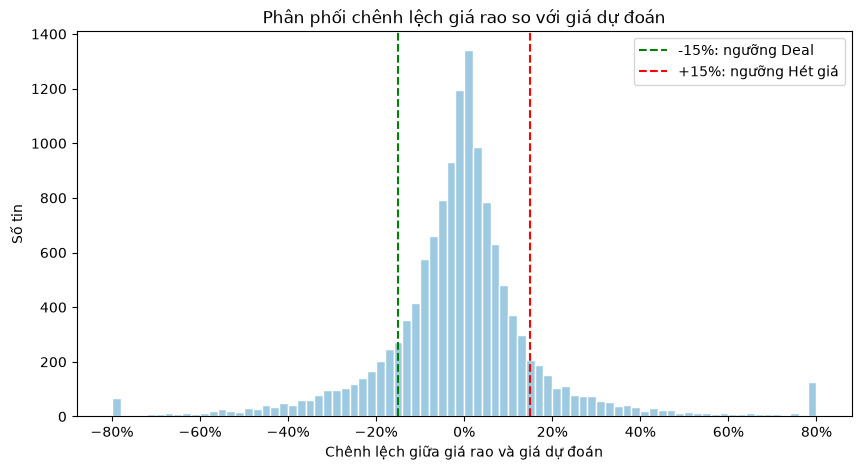

In [5]:
NGUONG = 0.15

plt.figure(figsize=(10, 5))
# cắt ở ±80% cho dễ nhìn, 2 cột ở 2 đầu là các tin lệch quá 80%
plt.hist(df["chenh_lech"].clip(-0.8, 0.8), bins=80, color="#9ecae1", edgecolor="white")
plt.axvline(-NGUONG, color="green", linestyle="--", label="-15%: ngưỡng Deal")
plt.axvline(NGUONG, color="red", linestyle="--", label="+15%: ngưỡng Hét giá")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel("Chênh lệch giữa giá rao và giá dự đoán")
plt.ylabel("Số tin")
plt.title("Phân phối chênh lệch giá rao so với giá dự đoán")
plt.legend()
plt.show()

In [6]:
def gan_nhan(chenh_lech, nguong=NGUONG):
    if chenh_lech < -nguong:
        return "Deal hời / Rẻ bất thường"
    if chenh_lech > nguong:
        return "Hét giá cao"
    return "Giá hợp lý"


df["nhan"] = df["chenh_lech"].apply(gan_nhan)

## 4. Thống kê theo nhãn

In [7]:
thu_tu = ["Deal hời / Rẻ bất thường", "Giá hợp lý", "Hét giá cao"]

thong_ke = df["nhan"].value_counts().reindex(thu_tu).to_frame("Số tin")
thong_ke["% tin"] = (thong_ke["Số tin"] / len(df) * 100).round(1)
thong_ke

,Số tin,% tin
nhan,,
Deal hời / Rẻ bất thường,1974,14.6
Giá hợp lý,10067,74.5
Hét giá cao,1479,10.9


In [8]:
# tỷ lệ từng nhãn trong 8 hãng có nhiều tin nhất (%)
top_hang = df["carbrand_name"].value_counts().head(8).index
theo_hang = pd.crosstab(df.loc[df["carbrand_name"].isin(top_hang), "carbrand_name"], df["nhan"], normalize="index")
(theo_hang[thu_tu] * 100).round(1).sort_values("Hét giá cao", ascending=False)

nhan,Deal hời / Rẻ bất thường,Giá hợp lý,Hét giá cao
carbrand_name,,,
Ford,18.1,66.3,15.6
Honda,9.3,80.1,10.6
Hyundai,12.3,77.6,10.1
Kia,12.5,78.4,9.1
VinFast,8.9,82.1,9.0
Toyota,10.2,81.3,8.5
Mitsubishi,13.1,79.2,7.7
Mazda,9.5,86.4,4.1


In [9]:
# so sánh TP.HCM, Hà Nội và các tỉnh còn lại (%)
khu_vuc = df["region_name"].where(df["region_name"].isin(["Hồ Chí Minh", "Hà Nội"]), "Tỉnh khác")
(pd.crosstab(khu_vuc, df["nhan"], normalize="index")[thu_tu] * 100).round(1)

nhan,Deal hời / Rẻ bất thường,Giá hợp lý,Hét giá cao
region_name,,,
Hà Nội,13.3,76.2,10.5
Hồ Chí Minh,11.7,77.3,11.0
Tỉnh khác,18.8,70.0,11.1


Nhận xét:

- Khoảng 3/4 số tin (74,5%) có giá hợp lý, 14,6% rẻ hơn thị trường và 10,9% đắt hơn thị trường. Số tin rẻ nhiều hơn số tin đắt, trên biểu đồ phần đuôi bên trái (rẻ) cũng dài hơn. Những tin rẻ hơn dự đoán quá nhiều chưa chắc là Deal thật mà có thể là xe có vấn đề hoặc người bán ghi sai thông tin, vì vậy nhãn này được gọi chung là "Deal hời / Rẻ bất thường" và người mua cần kiểm tra kỹ trước khi mua.
- Ford có tỷ lệ cả Deal lẫn hét giá cao nhất (khoảng 18% và 16%). Lý do có thể là Ford có nhiều phiên bản giá rất khác nhau trong cùng một dòng xe (Ranger bản thường, Wildtrak, Raptor) mà dữ liệu không có cột phiên bản. Mazda thì ngược lại, 86% tin có giá hợp lý.
- Các tỉnh ngoài TP.HCM và Hà Nội có tỷ lệ Deal cao hơn (18,8% so với khoảng 12-13%). Có thể giá ở tỉnh thật sự thấp hơn, hoặc do ít tin nên mô hình đoán kém hơn. Phần này sẽ kiểm tra thêm ở tuần 5.

In [10]:
# xem lại ví dụ Ford Ranger 2025 bản Raptor ở notebook 00
raptor = df[(df["carmodel_name"] == "Ranger") & (df["mfdate"] == 2025) & df["subject"].str.contains("raptor", case=False)]
raptor[["subject", "price_million", "gia_du_doan", "chenh_lech", "nhan"]].round(2)

,subject,price_million,gia_du_doan,chenh_lech,nhan
2605,Ford Ranger Raptor 2025 Đỏ Nhập khẩu,1160.0,820.89,0.41,Hét giá cao
2686,Raptor 2023 Màu Đỏ - 1 Chủ - Ngân hàng hỗ trợ 75%,995.0,839.09,0.19,Hét giá cao
2946,Ford Ranger Wildtrak Lên Raptor 2025 Đen 28.000km,810.0,687.88,0.18,Hét giá cao
4411,Ford Raptor 2025 Đỏ 37000 km,1165.0,764.65,0.52,Hét giá cao
6024,Ford Raptor 2025 Xám 8600 km,1159.0,819.17,0.41,Hét giá cao
8672,"Ford Ranger RAPTOR 4x4 AWD 2025, vay Ngân Hàng...",922.5,876.63,0.05,Giá hợp lý
12593,Raptor Đời Cao Giá Mềm Xe Bán Tại Hãng Ford,1135.0,675.62,0.68,Hét giá cao


6/7 tin Ford Ranger Raptor 2025 bị gắn nhãn Hét giá cao, dù giá rao (phần lớn trên 1,1 tỷ) là mức bình thường của bản Raptor. Nguyên nhân là dữ liệu không có cột phiên bản, mô hình chỉ thấy "Ford Ranger 2025" nên dự đoán theo mặt bằng giá của bản thường (khoảng 680-880 triệu).

Đây là giới hạn của cách làm hiện tại: nhãn Deal chỉ đúng khi mô hình định giá đúng. Tuần 5 sẽ xem lại trong phần phân tích sai số, ví dụ lấy thêm thông tin phiên bản từ tiêu đề.

## 5. Case study và phân tích sai số

*Làm ở tuần 5, sau khi có mô hình chính thức từ notebook 05.*

## 6. Kịch bản định giá đầu-cuối

*Làm ở tuần 5: nhập thông số một chiếc xe, trả về giá dự đoán, khoảng giá và nhãn Deal.*

## Tóm tắt tuần 4

- Đã dựng xong logic phát hiện Deal trên mô hình baseline (Random Forest, R² khoảng 0,875): so giá rao với giá dự đoán, lệch quá 15% thì gắn nhãn rẻ hoặc đắt.
- Kết quả: 14,6% tin là Deal hời / Rẻ bất thường, 74,5% giá hợp lý, 10,9% hét giá cao.
- Giới hạn: nhãn chỉ đúng khi mô hình định giá đúng; mô hình chưa biết phiên bản xe nên các bản cao cấp như Raptor dễ bị gắn nhầm là hét giá.
- Tuần 5: thay bằng mô hình chính thức từ notebook 05, kiểm tra lại ngưỡng, làm case study, phân tích sai số và kịch bản định giá đầu-cuối.